In [22]:
import pandas as pd
import spacy
import seaborn as sns
import matplotlib.pyplot as plt

!pip install pandas spacy seaborn matplotlib
!python -m spacy download en_core_web_sm

print("Libraries installed and spaCy model downloaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 84.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Libraries installed and spaCy model downloaded.


In [25]:
df = pd.read_csv('/content/NLP_Datasets/Tweets.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [26]:
tweets = df[['text', 'airline_sentiment']]
tweets.dropna(inplace=True)
print("Selected 'text' and 'airline_sentiment' columns and removed rows with missing values. Displaying the first 5 rows:")
tweets.head()

Selected 'text' and 'airline_sentiment' columns and removed rows with missing values. Displaying the first 5 rows:


/tmp/ipython-input-3045294951.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweets.dropna(inplace=True)


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [23]:
nlp = spacy.load('en_core_web_sm')
print("spaCy 'en_core_web_sm' model loaded.")

spaCy 'en_core_web_sm' model loaded.


In [29]:
import re

def clean_tweet(text):
    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 2. Remove mentions
    text = re.sub(r'@\w+', '', text)
    # 3. Remove emojis (basic regex, might not catch all new emojis)
    emoji_pattern = re.compile("[" # Start of pattern
                           "\U0001F600-\U0001F64F"  # emoticons
                           "\U0001F300-\U0001F5FF"  # symbols & pictographs
                           "\U0001F680-\U0001F6FF"  # transport & map symbols
                           "\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           "\U00002702-\U000027B0"  # Dingbats
                           "\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    # 4. Remove special characters and numbers, keep only alphanumeric and whitespace
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 5. Convert to lowercase
    text = text.lower()
    return text

tweets['cleaned_text'] = tweets['text'].apply(clean_tweet)
print("Tweet text cleaned and stored in 'cleaned_text' column. Displaying the first 5 rows with the new column:")
tweets.head()

Tweet text cleaned and stored in 'cleaned_text' column. Displaying the first 5 rows with the new column:


,text,airline_sentiment,cleaned_text
0,@VirginAmerica What @dhepburn said.,neutral,what said
1,@VirginAmerica plus you've added commercials t...,positive,plus youve added commercials to the experienc...
2,@VirginAmerica I didn't today... Must mean I n...,neutral,i didnt today must mean i need to take anothe...
3,@VirginAmerica it's really aggressive to blast...,negative,its really aggressive to blast obnoxious ente...
4,@VirginAmerica and it's a really big bad thing...,negative,and its a really big bad thing about it


In [42]:
from spacy.tokens import Doc
from spacy import Language

# 1. Set up a custom extension for the Doc object
if not Doc.has_extension('hashtags'):
    Doc.set_extension('hashtags', default=[])

# 2. Define and register the custom pipeline component
@Language.component("custom_hashtag_detector")
def hashtag_component(doc):
    hashtags = []
    for token in doc:
        if token.text.startswith('#') and len(token.text) > 1:
            hashtags.append(token.text)
    doc._.hashtags = hashtags
    return doc

print("Custom 'hashtag_detector' component defined.")

Custom 'hashtag_detector' component defined.


In [32]:
from spacy.tokens import Doc
from spacy import Language

# 1. Set up a custom extension for the Doc object
if not Doc.has_extension('hashtags'):
    Doc.set_extension('hashtags', default=[])

# 2. Define and register the custom pipeline component
@Language.component("custom_hashtag_detector")
def hashtag_component(doc):
    hashtags = []
    for token in doc:
        if token.text.startswith('#') and len(token.text) > 1:
            hashtags.append(token.text)
    doc._.hashtags = hashtags
    return doc

# 3. Add the registered component to the spaCy pipeline
nlp.add_pipe('custom_hashtag_detector', last=True)

print("Custom 'hashtag_detector' component added to spaCy pipeline.")
print("spaCy NLP pipeline components after adding custom component:", nlp.pipe_names)

Custom 'hashtag_detector' component added to spaCy pipeline.
spaCy NLP pipeline components after adding custom component: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'custom_hashtag_detector']


In [33]:
tweets['doc'] = tweets['cleaned_text'].apply(nlp)
print("Processed 'cleaned_text' column with spaCy NLP pipeline. Displaying the first 5 rows with the new 'doc' column:")
print(tweets.head())
print(f"Type of the first entry in 'doc' column: {type(tweets['doc'].iloc[0])}")

Processed 'cleaned_text' column with spaCy NLP pipeline. Displaying the first 5 rows with the new 'doc' column:
                                                text airline_sentiment  \
0                @VirginAmerica What @dhepburn said.           neutral   
1  @VirginAmerica plus you've added commercials t...          positive   
2  @VirginAmerica I didn't today... Must mean I n...           neutral   
3  @VirginAmerica it's really aggressive to blast...          negative   
4  @VirginAmerica and it's a really big bad thing...          negative   

                                        cleaned_text  \
0                                         what  said   
1   plus youve added commercials to the experienc...   
2   i didnt today must mean i need to take anothe...   
3   its really aggressive to blast obnoxious ente...   
4            and its a really big bad thing about it   

                                                 doc  
0                                 ( , what,  , said

In [34]:
def extract_lemmas_pos(doc):
    lemmas = [token.lemma_ for token in doc if token.text.strip()]
    pos_tags = [token.pos_ for token in doc if token.text.strip()]
    return lemmas, pos_tags

# Apply the function to the 'doc' column
lemma_pos_results = tweets['doc'].apply(lambda x: extract_lemmas_pos(x))

# Unpack the results into two new columns
tweets['lemmas'] = [result[0] for result in lemma_pos_results]
tweets['pos_tags'] = [result[1] for result in lemma_pos_results]

print("Extracted lemmas and POS tags into new 'lemmas' and 'pos_tags' columns. Displaying the first 5 rows:")
tweets.head()

Extracted lemmas and POS tags into new 'lemmas' and 'pos_tags' columns. Displaying the first 5 rows:


,text,airline_sentiment,cleaned_text,doc,lemmas,pos_tags
0,@VirginAmerica What @dhepburn said.,neutral,what said,"( , what, , said)","[what, say]","[PRON, VERB]"
1,@VirginAmerica plus you've added commercials t...,positive,plus youve added commercials to the experienc...,"( , plus, you, ve, added, commercials, to, the...","[plus, you, ve, add, commercial, to, the, expe...","[CCONJ, PRON, AUX, VERB, NOUN, ADP, DET, NOUN,..."
2,@VirginAmerica I didn't today... Must mean I n...,neutral,i didnt today must mean i need to take anothe...,"( , i, did, nt, today, must, mean, i, need, to...","[I, do, not, today, must, mean, I, need, to, t...","[PRON, VERB, PART, NOUN, AUX, VERB, PRON, VERB..."
3,@VirginAmerica it's really aggressive to blast...,negative,its really aggressive to blast obnoxious ente...,"( , its, really, aggressive, to, blast, obnoxi...","[its, really, aggressive, to, blast, obnoxious...","[PRON, ADV, ADJ, PART, VERB, ADJ, NOUN, ADP, P..."
4,@VirginAmerica and it's a really big bad thing...,negative,and its a really big bad thing about it,"( , and, its, a, really, big, bad, thing, abou...","[and, its, a, really, big, bad, thing, about, it]","[CCONJ, PRON, DET, ADV, ADJ, ADJ, NOUN, ADP, P..."


In [35]:
import re
from collections import Counter

def extract_hashtags(text):
    return re.findall(r'#\w+', text)

# Apply the function to the original 'text' column
tweets['extracted_hashtags'] = tweets['text'].apply(extract_hashtags)

# Create a single flat list of all hashtags, converting to lowercase
all_hashtags = [hashtag.lower() for sublist in tweets['extracted_hashtags'] for hashtag in sublist]

# Count the frequency of each unique hashtag
hashtag_counts = Counter(all_hashtags)

print("Top 10 most frequent hashtags (case-insensitive):")
for hashtag, count in hashtag_counts.most_common(10):
    print(f"{hashtag}: {count}")

Top 10 most frequent hashtags (case-insensitive):
#destinationdragons: 81
#fail: 69
#jetblue: 48
#unitedairlines: 45
#customerservice: 36
#usairways: 30
#americanairlines: 27
#neveragain: 27
#united: 26
#usairwaysfail: 26


/tmp/ipython-input-1050491352.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Hashtag', y='Frequency', data=hashtags_df, palette='viridis')


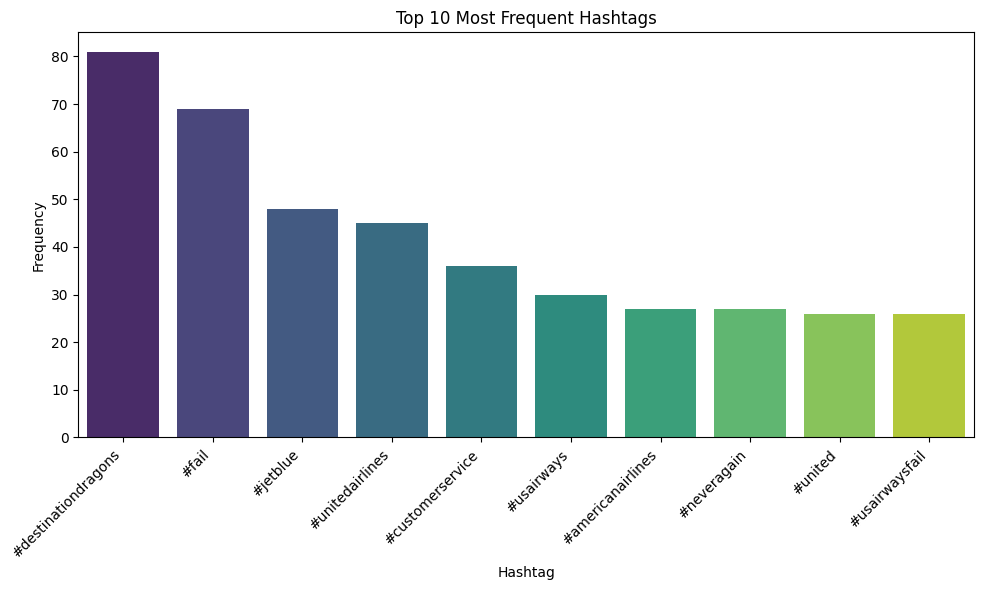

Bar chart of top 10 most frequent hashtags displayed.


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract top 10 most frequent hashtags
top_10_hashtags = hashtag_counts.most_common(10)
hashtags_df = pd.DataFrame(top_10_hashtags, columns=['Hashtag', 'Frequency'])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Hashtag', y='Frequency', data=hashtags_df, palette='viridis')
plt.title('Top 10 Most Frequent Hashtags')
plt.xlabel('Hashtag')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

print("Bar chart of top 10 most frequent hashtags displayed.")

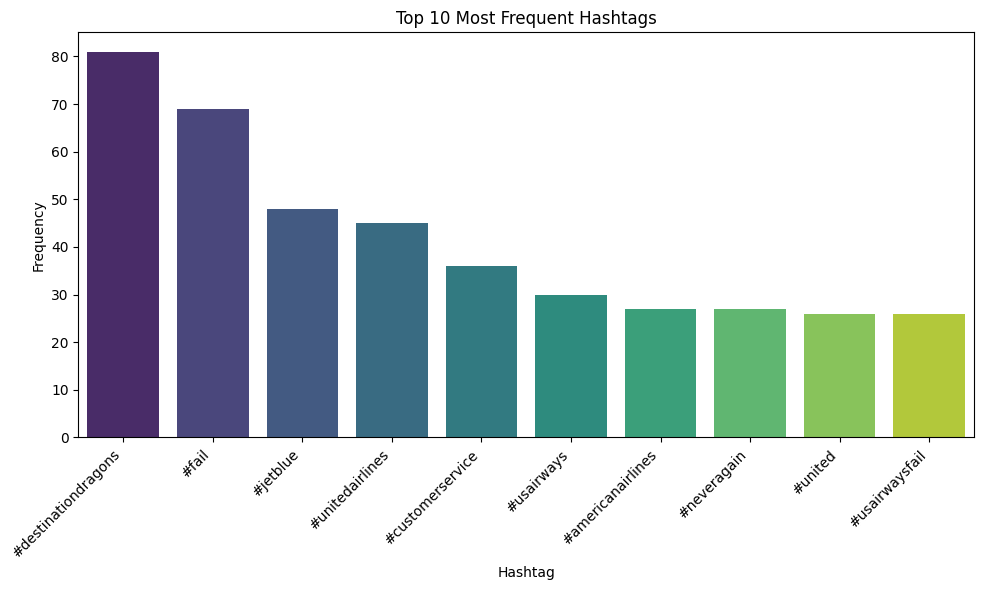

Bar chart of top 10 most frequent hashtags displayed.


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract top 10 most frequent hashtags
top_10_hashtags = hashtag_counts.most_common(10)
hashtags_df = pd.DataFrame(top_10_hashtags, columns=['Hashtag', 'Frequency'])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Hashtag', y='Frequency', hue='Hashtag', data=hashtags_df, palette='viridis', legend=False)
plt.title('Top 10 Most Frequent Hashtags')
plt.xlabel('Hashtag')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

print("Bar chart of top 10 most frequent hashtags displayed.")

In [38]:
from collections import Counter

# 1. Filter the DataFrame for negative sentiment tweets
negative_tweets = tweets[tweets['airline_sentiment'] == 'negative'].copy()

# 2. Create a single flat list of all POS tags from negative tweets
all_negative_pos_tags = [tag for sublist in negative_tweets['pos_tags'] for tag in sublist]

# 3. Compute the frequency distribution of these POS tags
negative_pos_tag_counts = Counter(all_negative_pos_tags)

# 4. Print the top 10 most frequent POS tags
print("Top 10 most frequent POS tags in negative sentiment tweets:")
for tag, count in negative_pos_tag_counts.most_common(10):
    print(f"{tag}: {count}")

Top 10 most frequent POS tags in negative sentiment tweets:
NOUN: 37487
VERB: 27196
PRON: 21006
ADP: 17688
AUX: 12871
DET: 10743
ADJ: 10003
ADV: 9334
PART: 7283
PROPN: 4816


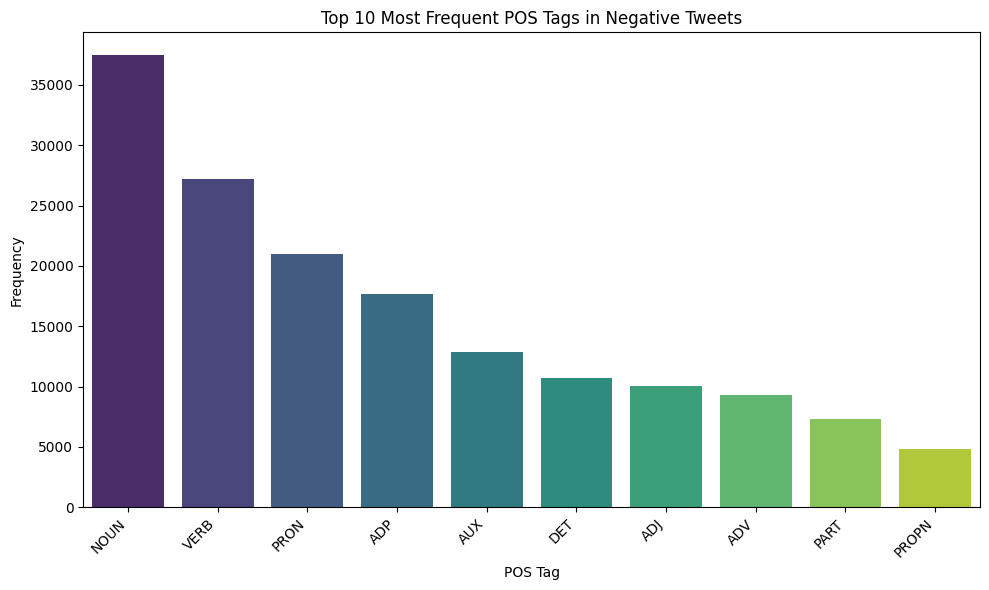

Bar chart of top 10 most frequent POS tags in negative tweets displayed.


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract top 10 most frequent POS tags
top_10_pos_tags = negative_pos_tag_counts.most_common(10)
# 2. Create a pandas DataFrame
pos_tags_df = pd.DataFrame(top_10_pos_tags, columns=['POS Tag', 'Frequency'])

# 3. Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='POS Tag', y='Frequency', hue='POS Tag', data=pos_tags_df, palette='viridis', legend=False)
# 4. Add a title
plt.title('Top 10 Most Frequent POS Tags in Negative Tweets')
# 5. Label axes
plt.xlabel('POS Tag')
plt.ylabel('Frequency')
# 6. Rotate x-axis labels
plt.xticks(rotation=45, ha='right')
# 7. Adjust layout
plt.tight_layout()
# 8. Display the plot
plt.show()

print("Bar chart of top 10 most frequent POS tags in negative tweets displayed.")